# Analisis de patrones de trafico en Gipuzkoa mediante Clustering

### Introducción
---

En esta práctica se analizarán datos del tráfico de Gipuzkoa con el objetivo de encontrar patrones de tráfico por hora y zona según la información de los datos de volumen, velocidad y estación de medición.

### Importar librerías necesarias

Se procedera a importar las librerías necesarias para una manipulacion de datos, visualizacion y modelo de los datos.

**Manipulación y Procesamiento de Datos**

In [3]:
import numpy as np
import pandas as pd

**Visualización de Datos**

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

**Modelado y evaluacion de Modelos**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


### Preprocesamiento de Datos
---

Se procederá a analizar un conjunto de tres datos según la fecha asignada (20251222), los cuales contienen la información sobre el tráfico de las diferentes carreteras de Gipuzkoa, incluyendo el volumen, la velocidad y las **estaciones de medición**.

El objetivo principal es realizar la carga de dichos datos, además de un análisis para comprobar si se encuentra algún error estructural en los datos. Este análisis inicial es esencial, ya que permite establecer una base de preprocesamiento, garantizando que la entrada de los algoritmos de clustering sea coherente y de alta calidad.

Los tres ficheros tendran unos parametros fijos:
- sep=";" -> los archivos están separados por punto y coma, un formato habitual en conjuntos de datos europeos.
- encoding="latin1" -> normalmente se suele utilizar el "utf-8", pero para evitar posibles fallor en "ñ" o tíldes e incluso simbolos extraños , utilizamos este.

#### **1. Estaciones**

Al inspeccionar el fichero de estaciones, se pudo observar que la estructura de los datos podría afectar la estrategia de integración. Esto se debe a que en la columna **System** se observa que coexisten dos tipos de información, probablemente el identificador de la carretera y un identificador del DataFrame.

Para comprobar mejor que los datos son correctos utilizaremos:

- data_estaciones.info(), porque permite ver la estructura del dataset y así comprobar si existe algún valor nulo y, sobre todo, que los dtypes sean los correctos.

En este caso no vamos a utilizar data_estaciones.describe(), porque está enfocada en un análisis más estadístico de variables numéricas, por lo que, aplicada a la tabla de estaciones, resulta poco relevante, ya que predominan columnas descriptivas, geográficas o de nombres.

In [6]:
data_estaciones = pd.read_csv("estaciones.csv", sep=";", encoding="latin1")
#Quitar espaciones en los nombres de las columnas
data_estaciones.columns = data_estaciones.columns.str.strip()
data_estaciones

,System,ETD code,System code,Description,Country code,Country,Municipality code,Municipality,Territory code,Territory,Postal code,GPSX,GPSY,X,Y
GI-2132,1,1,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-...",108,España,,,20,Gipuzkoa,,580428.65,4792191.27,-2.008765,43.278246,
GI-636,3,1,"[GI-636] 3-ETD PASAIA-IRUN, GI-636 pk 7,900, ...",108,España,53,LEZO,20,Gipuzkoa,20100,594584.89,4798000.13,-1.833330,43.328896,
N-634,11,1,"[N-634] 11-ETD SAN SEBASTIÁN-SANTANDER, N-634...",108,España,30,EIBAR,20,Gipuzkoa,20600,545592.28,4782339.10,-2.438889,43.192449,
N-I,12,1,"[N-I] 12-ETD VITORIA-GASTEIZ-LASARTE-ORIA, N-...",108,España,71,TOLOSA,20,Gipuzkoa,20400,575944.00,4778800.00,-2.065870,43.158142,
GI-20,16,1,"[GI-20] 16-ETD USURBIL, AP-8-ERRENTERIA,AP-8,...",108,España,69,DONOSTIA-SAN SEBASTIAN,20,Gipuzkoa,0,583607.00,4795202.00,-1.969142,43.305006,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GI-631,9157,1,"[GI-631] 9157-ETD ZUMARRAGA-ZUMAIA, GI-631 pk...",108,España,27,ZESTOA,20,Gipuzkoa,20740,559996.77,4788856.73,-2.260914,43.250126,
GI-2632,9159,1,"[GI-2632] 9159-ETD BEASAIN-BIZKAIA, GI-2632 p...",108,España,77,URRETXU,20,Gipuzkoa,20700,553008.18,4770764.28,-2.348733,43.087742,
GI-627,9211,1,"[GI-627] 9211-ETD ARABA-EIBAR, GI-627 pk 51,4...",108,España,74,BERGARA,20,Gipuzkoa,20570,547942.85,4779948.64,-2.410168,43.170779,
GI-2630,9259,1,"[GI-2630] 9259-ETD URRETXU-BERGARA, GI-2630 p...",108,España,51,LEGAZPI,20,Gipuzkoa,20230,554510.32,4769098.80,-2.330442,43.072638,


In [7]:
data_estaciones.info()

<class 'pandas.DataFrame'>
Index: 85 entries, GI-2132  to AP-636 
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   System             85 non-null     int64  
 1   ETD code           85 non-null     int64  
 2   System code        85 non-null     str    
 3   Description        85 non-null     int64  
 4   Country code       85 non-null     str    
 5   Country            85 non-null     str    
 6   Municipality code  85 non-null     str    
 7   Municipality       85 non-null     int64  
 8   Territory code     85 non-null     str    
 9   Territory          85 non-null     str    
 10  Postal code        85 non-null     float64
 11  GPSX               85 non-null     float64
 12  GPSY               85 non-null     float64
 13  X                  85 non-null     float64
 14  Y                  85 non-null     str    
dtypes: float64(4), int64(4), str(7)
memory usage: 10.6+ KB


#### **2. Volumen**

Se puede ver que los datos están organizados por fechas y con niveles horarios, lo que facilita en gran medida su posterior análisis.

Los fallos que sí posiblemente haya que corregir son la hora, debido a que la última es 24:00 y la correcta sería 00:00, además de sumarle un día, ya que corresponde al día siguiente.

Además, los datos de volumen se encuentran desglosados por carriles y cada carril según su tipo de vehículo, si son ligeros o pesados. Esto puede dificultar la aplicación de técnicas de clustering, ya que no existe una única variable que represente el tráfico, sino varias.

Todo esto se irá modificando en los siguientes apartados.

In [8]:
data_volumen = pd.read_csv("20251222_datosvolumen.csv", sep=";", encoding="latin1")
data_volumen.columns = data_volumen.columns.str.strip()
data_volumen

,Estacion,Fecha,Hora,Carril 1 ligeros,Carril 1 pesados,Carril 2 ligeros,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,Carril 4 pesados,Carril 5 ligeros,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados
0,1,22/12/2025,01:00,54,1,0,0,0,0,22,3,8,0,0,0
1,1,22/12/2025,02:00,26,2,0,0,0,0,7,1,4,0,0,0
2,1,22/12/2025,03:00,29,1,0,0,0,0,8,1,6,0,0,0
3,1,22/12/2025,04:00,12,4,0,0,0,0,4,1,6,0,0,0
4,1,22/12/2025,05:00,39,1,0,0,0,0,14,2,10,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12931,9259,28/12/2025,20:00,124,4,0,0,0,0,162,4,0,0,0,0
12932,9259,28/12/2025,21:00,109,7,0,0,0,0,146,6,0,0,0,0
12933,9259,28/12/2025,22:00,84,3,0,0,0,0,146,3,0,0,0,0
12934,9259,28/12/2025,23:00,46,3,0,0,0,0,77,2,0,0,0,0


In [9]:
data_volumen.info()

<class 'pandas.DataFrame'>
RangeIndex: 12936 entries, 0 to 12935
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Estacion          12936 non-null  int64
 1   Fecha             12936 non-null  str  
 2   Hora              12936 non-null  str  
 3   Carril 1 ligeros  12936 non-null  int64
 4   Carril 1 pesados  12936 non-null  int64
 5   Carril 2 ligeros  12936 non-null  int64
 6   Carril 2 pesados  12936 non-null  int64
 7   Carril 3 ligeros  12936 non-null  int64
 8   Carril 3 pesados  12936 non-null  int64
 9   Carril 4 ligeros  12936 non-null  int64
 10  Carril 4 pesados  12936 non-null  int64
 11  Carril 5 ligeros  12936 non-null  int64
 12  Carril 5 pesados  12936 non-null  int64
 13  Carril 6 ligeros  12936 non-null  int64
 14  Carril 6 pesados  12936 non-null  int64
dtypes: int64(13), str(2)
memory usage: 1.5 MB


> Analisis Explorativo

El análisis exploratorio permite observar que varias variables presentan distribuciones asimétricas y una gran concentración de valores bajos o nulos, especialmente en algunos carriles. Como resultado, podemos observar que no hay ningún elemento que deba ser eliminado.

In [120]:
data_volumen.describe()

,Fecha,datetime,volumen_ligeros,volumen_pesados,volumen_total,codigo_estacion
count,12936,12936,12936.000000,12936.000000,12936.000000,12936.0
mean,2025-12-25 01:00:00,2025-12-25 12:30:00,685.244666,48.968615,734.213281,846.883117
min,2025-12-22 00:00:00,2025-12-22 01:00:00,0.000000,0.000000,0.000000,1.0
25%,2025-12-23 00:00:00,2025-12-23 18:45:00,70.000000,4.000000,81.000000,84.0
50%,2025-12-25 00:00:00,2025-12-25 12:30:00,295.000000,18.000000,322.000000,120.0
75%,2025-12-27 00:00:00,2025-12-27 06:15:00,956.000000,59.000000,1020.250000,253.0
max,2025-12-29 00:00:00,2025-12-29 00:00:00,6287.000000,668.000000,6488.000000,9259.0
std,NaN,NaN,905.047171,76.186654,958.394451,2421.419977


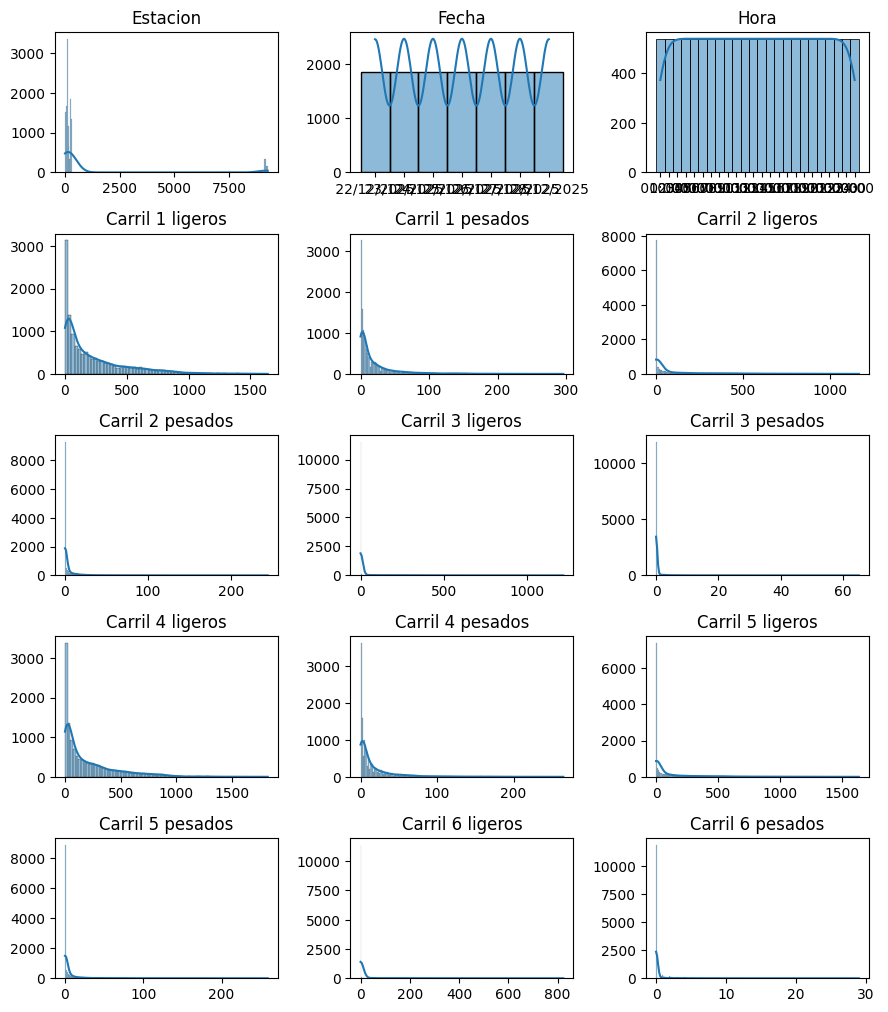

In [11]:
plt.figure(figsize=(9, 12))
for i, column in enumerate(data_volumen.columns):
    plt.subplot(6, 3, i+1)
    sns.histplot(data_volumen[column], kde=True)
    plt.xlabel("")
    plt.ylabel("")
    plt.title(f'{column}')
plt.tight_layout()
plt.show()

In [12]:
data = data_volumen.drop(columns = ["Fecha", "Hora"])

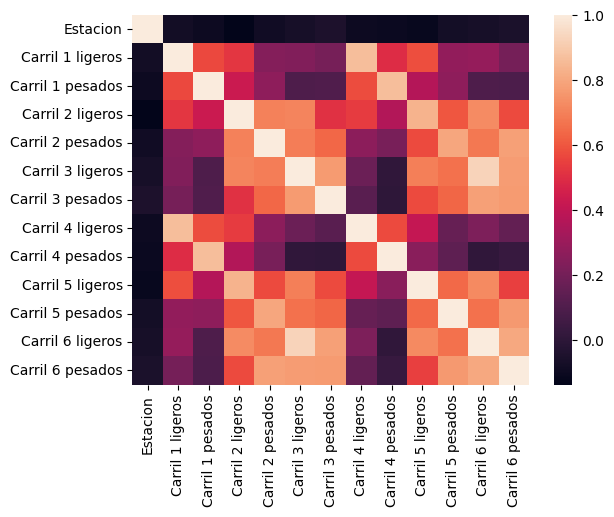

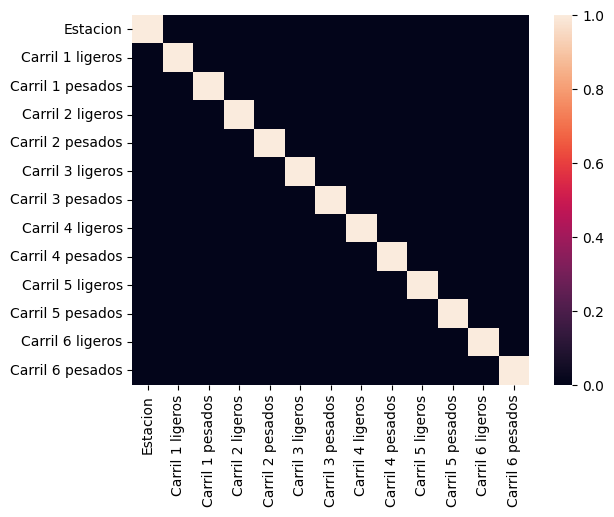

In [13]:
# cálculo de correlaciones
corrs = data.corr()
# graficar todas las correlaciones
sns.heatmap(corrs)
plt.show()
# destacar sólo aquellas características muy correlacionadas
sns.heatmap(corrs > .95)
plt.show()

En definitiva, con la visualización de estos datos podemos comprobar que ninguna columna debe ser eliminada, ya que todas están bien correlacionadas entre sí.

> Cambiamos el tipo de hora

Como comentamos en el punto anterior, el dato de hora tiene un error, ya que utiliza un formato de 24:00. Sin embargo, para poder realizar correctamente los cálculos temporales, comparaciones y agregaciones, es necesario que este dato de tipo string se convierta en datetime. Para ello utilizamos el siguiente código:

In [14]:
# Limpiar espacios
data_volumen["Hora"] = data_volumen["Hora"].str.strip()

# Cambiamos el formato de fecha año/mes/dia, para no crear una nueva columna simplemente sustituimos la fecha anterior por la nueva
data_volumen["Fecha"] = pd.to_datetime(data_volumen["Fecha"], dayfirst=True)

# Detectar 24:00
error_hora = data_volumen["Hora"].str.startswith("24:")

# Corregir hora
data_volumen.loc[error_hora, "Hora"] = data_volumen.loc[error_hora, "Hora"].str.replace("24:", "00:", regex=False)

# Sumamo un dia porque a las 00:00 ya es el dia siguiente
data_volumen.loc[error_hora, "Fecha"] = data_volumen.loc[error_hora, "Fecha"] + pd.Timedelta(days=1)

# Crear datetime
data_volumen["datetime"] = pd.to_datetime(
    data_volumen["Fecha"].dt.strftime("%Y-%m-%d") + " " + data_volumen["Hora"]
)

> Encapsulacion de los carriles y tipos de vehiculos

Como se observa en nuestra tabla principal, en la columna de carriles podemos ver muchos elementos a 0, por lo que aportan poca información. Para ello realizaremos una encapsulación de las 6 columnas (Carril 2, 3, 4, 5 y 6) en tres columnas principales (volumen_ligeros, volumen_pesados y volumen_total).

Esto es fundamental para realizar un correcto escalado de los datos, ya que trabajar con columnas con muchos valores a 0 es poco eficiente al utilizar técnicas de clustering.

In [15]:
# Seleccionar columnas automáticamente, en lugar de escribir cada una de las columnas que contienen "ligeros" o "pesados"
# se seleccionan automáticamente con una comprensión de listas
cols_ligeros = [c for c in data_volumen.columns if "ligeros" in c.lower()]
cols_pesados = [c for c in data_volumen.columns if "pesados" in c.lower()]

data_volumen["volumen_ligeros"] = data_volumen[cols_ligeros].sum(axis=1)
data_volumen["volumen_pesados"] = data_volumen[cols_pesados].sum(axis=1)

data_volumen["volumen_total"] = (
    data_volumen["volumen_ligeros"] + data_volumen["volumen_pesados"]
)

Eliminamos columnas innecesarias por ahora, para ello utilizamos la misma tecnica anterior y agrupamos todas las columnas que tengan "Carril"

In [16]:
cols_carriles = [c for c in data_volumen.columns if "carril" in c.lower()]

data_volumen = data_volumen.drop(columns=cols_carriles)

In [17]:
data_volumen.head()

,Estacion,Fecha,Hora,datetime,volumen_ligeros,volumen_pesados,volumen_total
0,1,2025-12-22,01:00,2025-12-22 01:00:00,84,4,88
1,1,2025-12-22,02:00,2025-12-22 02:00:00,37,3,40
2,1,2025-12-22,03:00,2025-12-22 03:00:00,43,2,45
3,1,2025-12-22,04:00,2025-12-22 04:00:00,22,5,27
4,1,2025-12-22,05:00,2025-12-22 05:00:00,63,6,69


#### **3. Velocidad**

Ademas añadimos *decimal=","* para evitar confusiones en las velocidades debido a la confusion de que y cambiamos las comas por puntos y asi tener una mejor lectura


Al hacer una visualización previa de la tabla podemos comprobar que tiene el mismo problema con la hora y, además, hay que eliminar una columna que no tiene ningún dato.

In [122]:
data_velocidad = pd.read_csv("20251222_datosvelocidad.csv", sep=";", encoding="latin1", decimal=",")
data_estaciones.columns = data_estaciones.columns.str.strip()
data_velocidad


,Fecha,Hora,Sistema,ETD,Detector,0-50 (km/h),50-80 (km/h),80-120 (km/h),120-255 (km/h),Velocidad media (km/h),0-6 (m),6-999 (m),Vehículos totales,Unnamed: 13
0,2025-12-22,01:00:00 - 01:30:00,N-634,"[N-634] 40-ETD SAN SEBASTIÁN-SANTANDER, N-634 ...",Lento SANTANDER,0,7,0,0,65.00,7,0,7,NaN
1,2025-12-22,01:00:00 - 01:30:00,N-634,"[N-634] 40-ETD SAN SEBASTIÁN-SANTANDER, N-634 ...",Lento SAN SEBASTIÁN,0,5,0,0,65.00,5,0,5,NaN
2,2025-12-22,01:00:00 - 01:30:00,AP-8,"[AP-8] 257-ETD FRANCIA-BILBAO, AP-8 pk 0,000, ...",Central FRANCIA,0,14,7,0,76.67,20,1,21,NaN
3,2025-12-22,01:00:00 - 01:30:00,AP-8,"[AP-8] 257-ETD FRANCIA-BILBAO, AP-8 pk 0,000, ...",Lento BILBAO,2,41,14,0,72.19,24,33,57,NaN
4,2025-12-22,01:00:00 - 01:30:00,AP-8,"[AP-8] 257-ETD FRANCIA-BILBAO, AP-8 pk 0,000, ...",Central BILBAO,0,0,1,0,100.00,1,0,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81559,2025-12-28,24:30:00 - 00:00:00,GI-40,"[GI-40] 316-ETD ENLACE HOSPITAL-A LA GI-20, GI...",Lento ENLACE HOSPITAL,0,2,29,3,101.47,31,3,34,NaN
81560,2025-12-28,24:30:00 - 00:00:00,GI-40,"[GI-40] 316-ETD ENLACE HOSPITAL-A LA GI-20, GI...",Central A LA GI-20,0,2,2,1,94.00,5,0,5,NaN
81561,2025-12-28,24:30:00 - 00:00:00,GI-40,"[GI-40] 316-ETD ENLACE HOSPITAL-A LA GI-20, GI...",Lento A LA GI-20,1,9,14,0,83.75,20,4,24,NaN
81562,2025-12-28,24:30:00 - 00:00:00,GI-2630,"[GI-2630] 9259-ETD URRETXU-BERGARA, GI-2630 pk...",Lento URRETXU,0,8,13,0,86.67,19,2,21,NaN


> Eliminamos la columna *Unnamed: 13*, debido a que solo contiene elementos nulos

In [123]:
data_velocidad = data_velocidad.drop(columns=["Unnamed: 13"])#, remplace=True)
print("columna eliminada")

columna eliminada


> Modificamos la hora

Para modificar esta hora se tuvo que realizar de forma diferente, ya que no solo llega hasta 24:00, sino que alcanza hasta las 24:30. Esto quiere decir que, además de indicar que han pasado 30 minutos, también hay que informar de que ha pasado un día.

Se crea una columna *datetime* que refleja el inicio de cada intervalo de medición. Esta columna será la clave temporal para cruzar con los datos de volumen.

In [129]:

# Extraemos únicamente la hora de inicio del intervalo (ej: "01:00:00")
data_velocidad["Hora_inicio"] = data_velocidad["Hora"].str.split("-").str[0].str.strip()

# Convertir Fecha a datetime
data_velocidad["Fecha"] = pd.to_datetime(data_velocidad["Fecha"], dayfirst=True, format="mixed")

# Convertir la hora en Timedelta: permite manejar "24:30:00" correctamente
# pd.to_timedelta interpreta "24:30:00" como 1 día y 30 minutos
data_velocidad["td_hora"] = pd.to_timedelta(data_velocidad["Hora_inicio"])
data_velocidad["datetime"] = data_velocidad["Fecha"] + data_velocidad["td_hora"]

# Agregar velocidad por ETD y datetime (promedio de detectores por estación y franja)
velodidad = (
    data_velocidad
    .groupby(["ETD", "datetime"], as_index=False)
    .agg(velocidad_media=("Velocidad media (km/h)", "mean"),
         vehiculos_vel=("Vehículos totales", "sum"))
)

print(f"Dataset de velocidad agregado: {velodidad.shape}")
velodidad.head()

Dataset de velocidad agregado: (25584, 4)


,ETD,datetime,velocidad_media,vehiculos_vel
0,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",2025-12-22 01:00:00,107.730000,135
1,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",2025-12-22 01:30:00,108.970000,144
2,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",2025-12-22 02:00:00,100.870000,109
3,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",2025-12-22 02:30:00,96.836667,118
4,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",2025-12-22 03:00:00,101.082500,103


> Analisis Explorativo

In [132]:
data_velocidad.describe()

,Fecha,0-50 (km/h),50-80 (km/h),80-120 (km/h),120-255 (km/h),Velocidad media (km/h),0-6 (m),6-999 (m),Vehículos totales,td_hora,datetime
count,81564,81564.000000,81564.000000,81564.000000,81564.000000,81564.000000,81564.000000,81564.000000,81564.000000,81564,81564
mean,2025-12-24 23:51:06.117404,11.871561,50.303063,51.241173,3.029976,76.476885,108.679381,7.766392,116.445773,0 days 12:53:23.869354,2025-12-25 12:44:29.986759
min,2025-12-22 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0 days 01:00:00,2025-12-22 01:00:00
25%,2025-12-23 00:00:00,0.000000,2.000000,1.000000,0.000000,62.420000,13.000000,0.000000,15.000000,0 days 07:00:00,2025-12-23 18:30:00
50%,2025-12-25 00:00:00,0.000000,12.000000,11.000000,0.000000,79.640000,56.000000,2.000000,60.000000,0 days 13:00:00,2025-12-25 13:00:00
75%,2025-12-27 00:00:00,3.000000,54.000000,61.000000,1.000000,97.420000,163.000000,8.000000,173.000000,0 days 19:00:00,2025-12-27 07:00:00
max,2025-12-28 00:00:00,771.000000,805.000000,528.000000,149.000000,140.000000,911.000000,149.000000,934.000000,1 days 00:30:00,2025-12-29 00:30:00
std,NaN,41.421377,90.937715,84.209484,9.360077,25.120872,129.128050,14.115127,137.583215,0 days 06:52:34.739938,NaN


In [133]:
data_velocidad.info()

<class 'pandas.DataFrame'>
RangeIndex: 81564 entries, 0 to 81563
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype          
---  ------                  --------------  -----          
 0   Fecha                   81564 non-null  datetime64[us] 
 1   Hora                    81564 non-null  str            
 2   Sistema                 81564 non-null  str            
 3   ETD                     81564 non-null  str            
 4   Detector                81564 non-null  str            
 5   0-50 (km/h)             81564 non-null  int64          
 6   50-80 (km/h)            81564 non-null  int64          
 7   80-120 (km/h)           81564 non-null  int64          
 8   120-255 (km/h)          81564 non-null  int64          
 9   Velocidad media (km/h)  81564 non-null  float64        
 10  0-6 (m)                 81564 non-null  int64          
 11  6-999 (m)               81564 non-null  int64          
 12  Vehículos totales       81564 non-null  int

In [134]:
data_velocidad.describe()

,Fecha,0-50 (km/h),50-80 (km/h),80-120 (km/h),120-255 (km/h),Velocidad media (km/h),0-6 (m),6-999 (m),Vehículos totales,td_hora,datetime
count,81564,81564.000000,81564.000000,81564.000000,81564.000000,81564.000000,81564.000000,81564.000000,81564.000000,81564,81564
mean,2025-12-24 23:51:06.117404,11.871561,50.303063,51.241173,3.029976,76.476885,108.679381,7.766392,116.445773,0 days 12:53:23.869354,2025-12-25 12:44:29.986759
min,2025-12-22 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0 days 01:00:00,2025-12-22 01:00:00
25%,2025-12-23 00:00:00,0.000000,2.000000,1.000000,0.000000,62.420000,13.000000,0.000000,15.000000,0 days 07:00:00,2025-12-23 18:30:00
50%,2025-12-25 00:00:00,0.000000,12.000000,11.000000,0.000000,79.640000,56.000000,2.000000,60.000000,0 days 13:00:00,2025-12-25 13:00:00
75%,2025-12-27 00:00:00,3.000000,54.000000,61.000000,1.000000,97.420000,163.000000,8.000000,173.000000,0 days 19:00:00,2025-12-27 07:00:00
max,2025-12-28 00:00:00,771.000000,805.000000,528.000000,149.000000,140.000000,911.000000,149.000000,934.000000,1 days 00:30:00,2025-12-29 00:30:00
std,NaN,41.421377,90.937715,84.209484,9.360077,25.120872,129.128050,14.115127,137.583215,0 days 06:52:34.739938,NaN


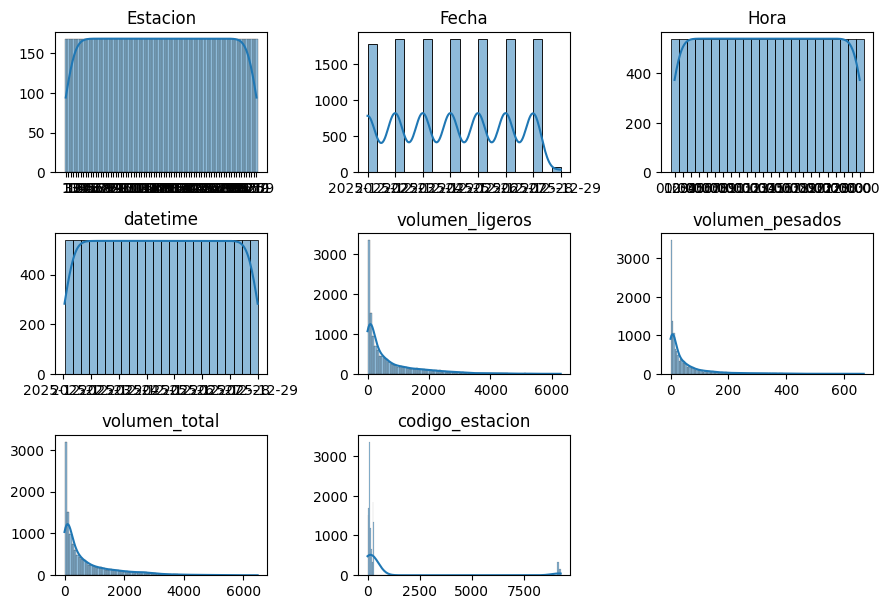

In [135]:
plt.figure(figsize=(9, 12))

for i, column in enumerate(data_volumen.columns):
    plt.subplot(6, 3, i+1)
    sns.histplot(data_volumen[column], kde=True)
    plt.xlabel("")
    plt.ylabel("")
    plt.title(f'{column}')
plt.tight_layout()
plt.show()

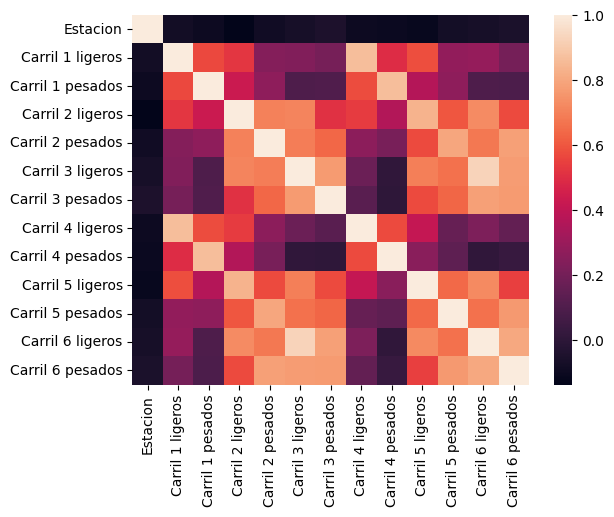

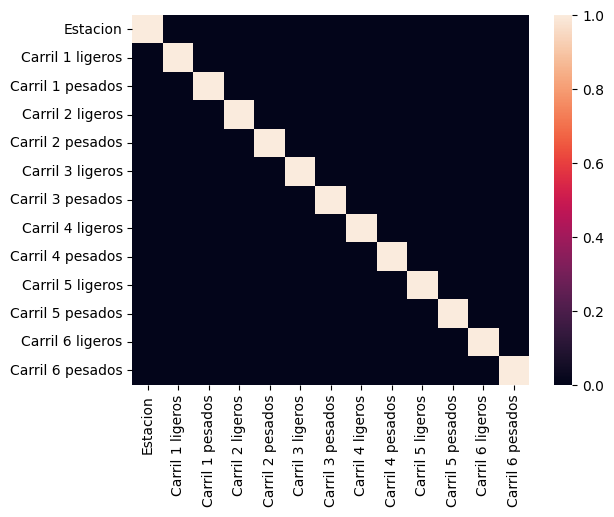

In [27]:
# cálculo de correlaciones
corrs = data.corr()
# graficar todas las correlaciones
sns.heatmap(corrs)
plt.show()
# destacar sólo aquellas características muy correlacionadas
sns.heatmap(corrs > .95)
plt.show()

# Unir tablas

**Velocidad + Estación**

Primero se procedera a la union de las tablas de velocidad y estacion comprobando que tienen un identificador de columnas donde comparten la misma informacion y por lo tanto por donde pueden unirse la tabla y realizar un merge exitoso

- data_estacion = System code
- data_velocidad = ETD	

In [ ]:
#Utilizamos ".strip" para eliminar cualquier espacio en blanco
data_velocidad["ETD"] = data_velocidad["ETD"].astype(str).str.strip()
data_estaciones["System code"] = data_estaciones["System code"].astype(str).str.strip()

In [137]:
merge_ve = data_velocidad.merge(
    data_estaciones[["System code", "System", "Municipality", "GPSX", "GPSY"]],
    left_on="ETD",
    right_on="System code",
    how="left"
)

Se hace un redondeo de datetime a la hora para poder cruzar con volumen, porque es horario

In [138]:
merge_ve["datetime_hora"] = merge_ve["datetime"].dt.floor("h")

In [139]:
vel_horaria = (
    merge_ve
    .groupby(["System", "datetime_hora"], as_index=False)
    .agg(velocidad_media=("Velocidad media (km/h)", "mean"),
         Municipality=("Municipality", "first"),
         GPSX=("GPSX", "first"),
         GPSY=("GPSY", "first"))
)

Con esta unión, procederemos a unir la tabla merge_ve con la de volumne, para ello el identifcador que vemos en comun es :
- merge_ve = System
- data_volumen = Estacion	

In [140]:
df_final = data_volumen.merge(
    merge_ve,
    left_on=["Estacion", "datetime"],
    right_on=["System", "datetime"],
    how="inner"
)

In [141]:
print(f"Dataset final: {df_final.shape}")
print(f"Estaciones únicas: {df_final['Estacion'].nunique()}")
print(f"Rango de fechas: {df_final['datetime'].min()} → {df_final['datetime'].max()}")
df_final.head()

Dataset final: (40782, 29)
Estaciones únicas: 77
Rango de fechas: 2025-12-22 01:00:00 → 2025-12-29 00:00:00


,Estacion,Fecha_x,Hora_x,datetime,volumen_ligeros,volumen_pesados,volumen_total,codigo_estacion,Fecha_y,Hora_y,...,6-999 (m),Vehículos totales,Hora_inicio,td_hora,System code,System,Municipality,GPSX,GPSY,datetime_hora
0,1,2025-12-22,01:00,2025-12-22 01:00:00,84,4,88,1,2025-12-22,01:00:00 - 01:30:00,...,0,3,01:00:00,0 days 01:00:00,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",1,20,4792191.27,-2.008765,2025-12-22 01:00:00
1,1,2025-12-22,01:00,2025-12-22 01:00:00,84,4,88,1,2025-12-22,01:00:00 - 01:30:00,...,1,11,01:00:00,0 days 01:00:00,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",1,20,4792191.27,-2.008765,2025-12-22 01:00:00
2,1,2025-12-22,01:00,2025-12-22 01:00:00,84,4,88,1,2025-12-22,01:00:00 - 01:30:00,...,0,26,01:00:00,0 days 01:00:00,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",1,20,4792191.27,-2.008765,2025-12-22 01:00:00
3,1,2025-12-22,02:00,2025-12-22 02:00:00,37,3,40,1,2025-12-22,02:00:00 - 02:30:00,...,1,13,02:00:00,0 days 02:00:00,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",1,20,4792191.27,-2.008765,2025-12-22 02:00:00
4,1,2025-12-22,02:00,2025-12-22 02:00:00,37,3,40,1,2025-12-22,02:00:00 - 02:30:00,...,0,3,02:00:00,0 days 02:00:00,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",1,20,4792191.27,-2.008765,2025-12-22 02:00:00


# K-means

Se selecciona el algoritmo K-means debido a su eficiencia y a su capacidad para trabajar con conjuntos de datos de tamaño elevado, como en este caso, donde se analizan variables de volumen y velocidad del tráfico.

Además, K-means facilita la interpretación de los grupos mediante el uso de centroides, lo que permite identificar distintos perfiles de tráfico de forma clara.

Frente a otras alternativas, como DBSCAN, K-means resulta más adecuado en este contexto, ya que presenta un menor coste computacional y un comportamiento más estable para este tipo de datos.

Para agilizar el proceso seleccionaremos las tablas que mas nos interesa para el clustering

In [144]:
features = [
    "volumen_total",
    "volumen_ligeros",
    "volumen_pesados",
    "Velocidad media (km/h)"
]

data_clustering = df_final[features]

Antes de aplicar el algoritmo, vamos a renderizar las variables, esto lo haremos para que tengan una media de 0 y una desviacion standar de 1.

Esto se hacer porque ciertas variables que tienen mayor rango pueden predominar al realizar el agrupamiento y producir una distorsion de los resultados

In [145]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_clustering)

scaled_data = pd.DataFrame(scaled_data, columns=data_clustering.columns)

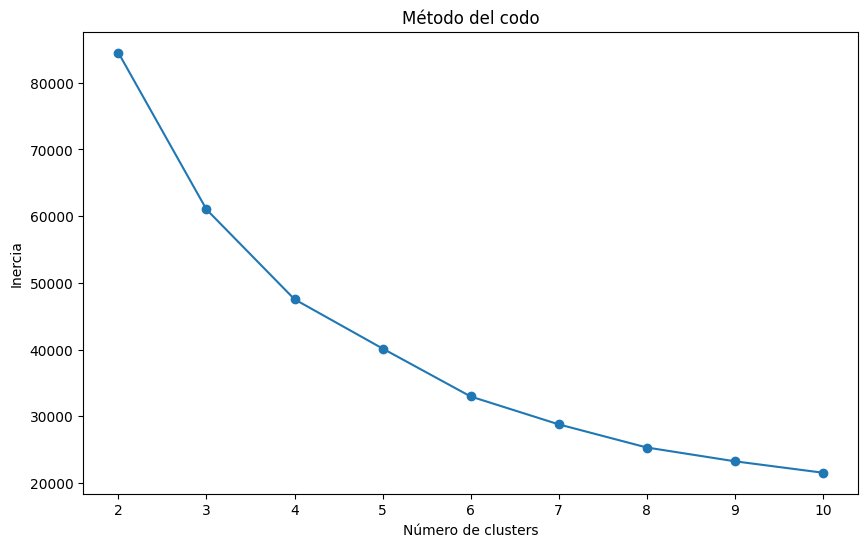

In [146]:
inertias = []

for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    kmeans.fit(scaled_data)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(2,11), inertias, marker='o')
plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.show()

Visualizando la grafica del Metodo del codo, aunque no es muy marcado, el Cluster estaria en 4, debido que es donde mas se nota el pico, ademas se ve casi lineas debido a la sintonia de los datos

El valor que nos proporcione nos ayduara a comparar distintas configuraciones de K y seleccionar la que ofrece una mejor estructura de agrupamiento.

In [149]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)
df_final["kmeans_cluster"] = kmeans_labels
print("Silhouette Score KMeans:", silhouette_score(scaled_data, kmeans_labels))

Silhouette Score KMeans: 0.35896896904752734


Se nos muestra un resultado medio estable (0.35), es decir nos indica que tiene una separacion moderada entre los cluster.

Lo que se hace una buena estructura de os datos, auqnue existe un solapamiento de los mismos

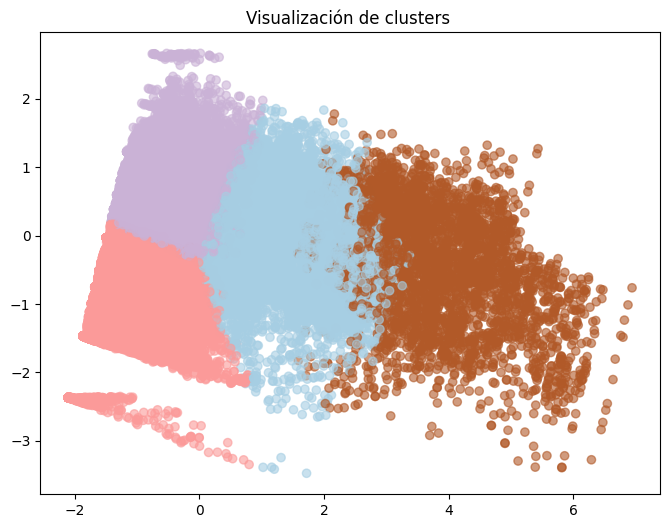

In [156]:
# KMeans
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)
df_final["kmeans_cluster"] = kmeans_labels

# transformación datos a 2D para poder visualizarlos
pca = PCA(2)
data_2d = pca.fit_transform(scaled_data)

# visualización K-means
plt.figure(figsize=(8, 6))
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=kmeans_labels, cmap="Paired", alpha=0.6)
plt.title("Visualización de clusters ")

plt.show()

La visualización muestra que existen cuatro grupos diferenciados, aunque con cierto solapamiento entre ellos, especialmente en la zona central.

Algunos clusters presentan una separación clara, mientras que otros se solapan parcialmente, lo que indica que los patrones de tráfico no están completamente diferenciados. Este comportamiento es coherente con el valor del coeficiente silhouette obtenido.

## Análisis de clusters


## Conclusiones

Al hacer un analisid del clustering se ha identificado los diferentes perfiles de tráfico a partir de variables como el volumen y la velocidad media.

Los resultados obtenidos son:

- Cluster 3: Es el que mayor volumen medio tiene con una velocidad de 86 km/h, lo que sugiere da a entender que las lineas principales tienen una alta capacidad y tráfico intenso pero fluido.

- Cluster 0: tambien es elevado pero no llega a puntos como el anterior, lo que indica que existe un tráfico denso pero sin congestión significativa.

- Cluster 2: los datos son medio bajos, representando situaciones de tráfico fluido con baja densidad, posiblemente en horas valle o zonas menos transitadas.

- Cluster 1: son los valores mas bajos, lo que podría corresponder a situaciones específicas como tráfico urbano, incidencias o condiciones particulares de circulación.

Por tanto, el uso de K-means ha permitido identificar estructuras relevantes en los datos y caracterizar distintos comportamientos del tráfico en función de su intensidad y velocidad.


In [164]:
cluster_summary = df_final.groupby("kmeans_cluster")[
    ["volumen_total", "Velocidad media (km/h)"]
].agg(["mean", "std", "count"])

cluster_summary

volumen_total                     Velocidad media (km/h)  \
                        mean          std  count                   mean   
kmeans_cluster                                                            
0                1986.786286   597.537309   8371              87.822812   
1                 336.579250   393.369320  13735              47.324994   
2                 412.570163   320.905400  15008              91.998254   
3                3403.469738  1005.328201   3668              86.161835   

                                  
                      std  count  
kmeans_cluster                    
0               17.961866   8371  
1               20.102909  13735  
2               12.716630  15008  
3               17.606430   3668